(haldane-hwf-nb)=
# Hybrid Wannier functions in the Haldane model

Calculates Berry phases for the Haldane model and compares it to the hybrid Wannier centers for a ribbon of the Haldane model.

In [1]:
from pythtb import TBModel, WFArray, Lattice, Mesh
import numpy as np
import matplotlib.pyplot as plt

First, we set up the the Haldane model

In [2]:
# define lattice vectors and orbitals and make model
lat_vecs = [[1, 0], [1/2, np.sqrt(3)/2]]
orb_vecs = [[1/3, 1/3], [2/3, 2/3]]
lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=[0, 1])

my_model = TBModel(lat)

# set model parameters
delta = -0.2
t = -1.0
t2 = 0.05 - 0.15j
t2c = t2.conjugate()

# set on-site energies and hoppings
my_model.set_onsite([-delta, delta])
my_model.set_hop(t, 0, 1, [0, 0])
my_model.set_hop(t, 1, 0, [1, 0])
my_model.set_hop(t, 1, 0, [0, 1])
my_model.set_hop(t2, 0, 0, [1, 0])
my_model.set_hop(t2, 1, 1, [1, -1])
my_model.set_hop(t2, 1, 1, [0, 1])
my_model.set_hop(t2c, 1, 1, [1, 0])
my_model.set_hop(t2c, 0, 0, [1, -1])
my_model.set_hop(t2c, 0, 0, [0, 1])

Next, we set up the `Mesh` object and build the k-point grid.

In [3]:
# number of discretized sites or k-points in the mesh in directions 0 and 1
nk0 = 100
nk1 = 300

mesh = Mesh(dim_k=2, axis_types=['k', 'k'])
mesh.build_grid(shape=(nk0, nk1))
print(mesh)

Mesh Summary
Type: grid
Dimensionality: 2 k-dim(s) + 0 λ-dim(s)
Number of mesh points: 30000
Full shape: (100, 300, 2)
k-axes: [Axis(type=k, name=k_0, size=100), Axis(type=k, name=k_1, size=300)]
λ-axes: []
Is a torus in k-space (all k-axes wind BZ): yes
Looped axes: (axis 0 loops component 0), (axis 1 loops component 1)
BZ-winding axes: (axis 0 winds component 0), (axis 1 winds component 1)
Endpoint axes: None


This allows us to initialize the `WFArray` which we will use to store the energy eigenstates. With this class, we can compute Berry phases and hybrid Wannier centers.

In [4]:
my_array = WFArray(lat, mesh)
my_array.solve_model(my_model)

To compute the Berry phase, we will use the `berry_phase` method from the `WFArray` class. This method takes the band indices (`state_idx`) and the direction of the mesh grid that will form the closed loop of states (`dir`). Optionally, we can also set `contin=True` which picks a branch of the Berry phase such that the phase at neighboring k-points are continuous.

In [5]:
phi_0 = my_array.berry_phase(0, state_idx=[0], contin=True)

We will now create a finite model along the `0` direction by calling `TBModel.cut_piece`. The `ribbon_model` will then be finite in the `0` direction and periodic in the `1` direction. We choose to omit periodic boundary conditions in the `0` direction by setting `glue_edgs=False`.

In [6]:
# create Haldane ribbon that is finite along direction 0
n_layers = 10
ribbon_model = my_model.cut_piece(n_layers, periodic_dir=0, glue_edges=False)

Next, we diagonalize the model along a 1D momentum space path using the `solve_ham` method. We construct this path using the `k_path` method of the `TBModel` class, which generates a set of k-points along a specified path in the Brillouin zone.

In [7]:
(k_vec, k_dist, k_node) = ribbon_model.k_path([0.0, 0.5, 1.0], nk1, report=False)
k_label = [r"$0$", r"$\pi$", r"$2\pi$"]

# solve ribbon model to get eigenvalues and eigenvectors
rib_eval, rib_evec = ribbon_model.solve_ham(k_vec, return_eigvecs=True)

# Fermi level, relevant for edge states of ribbon
efermi = 0.25

# shift bands so that the fermi level is at zero energy
rib_eval -= efermi

In [8]:
# find k-points at which number of states below the Fermi level changes
jump_k = []
for i in range(rib_eval.shape[0] - 1):
    nocc_i = np.sum(rib_eval[i, :] < 0)
    nocc_ip = np.sum(rib_eval[i + 1, :] < 0)
    if nocc_i != nocc_ip:
        jump_k.append(i)

The figure below contrasts the ribbon (finite) and bulk (periodic) perspectives:

- **Top panel** – Ribbon band structure. Thin **black lines** are the raw ribbon bands. The overlaid **colored dots** are the same bands, but colored by the expectation value of the orbital position along the finite lattice direction 0 ($\mathbf{a}_1 = \hat{x}$). Values near 0 correspond to the lower edge; values near $N_{\rm layers}$ correspond to the upper edge. The dashed horizontal line marks the Fermi energy.

- **Bottom panel** – Hybrid Wannier information. The **black curves** are the bulk hybrid Wannier centres (and their periodic images) obtained from the periodic model. The **colored markers** are the discrete hybrid Wannier centres extracted from the finite ribbon; their color encodes the center in units of layers. Vertical dotted guides highlight the $k$-points where the ribbon edge modes cross the Fermi level.

:::{seealso}
Fig. 3 in _Phys. Rev. Lett. 102, 107603 (2009)_.
:::


In [9]:
pos_exps = []
for i in range(rib_evec.shape[0]):
    # get expectation value of the position operator for states at i-th kpoint
    pos_exp = ribbon_model.position_expectation(rib_evec[i, :], dir=0)
    pos_exps.append(pos_exp)
pos_exps = np.array(pos_exps)

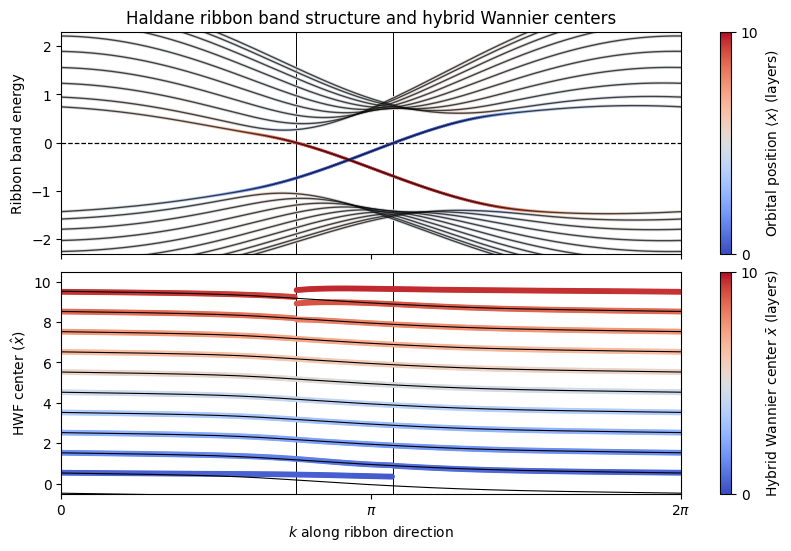

In [11]:
fig, (ax1, ax2) = plt.subplots(
    2, 
    1, 
    figsize=(10, 6), 
    gridspec_kw={"height_ratios": (1.0, 1.0), "hspace": 0.08},
    sharex=True,
    )

# plot bandstructure of the ribbon
ax1.plot(k_dist, rib_eval, c="k", alpha=0.7, lw=1, zorder=2)

# plot band structure with position expec. coloring
for band in range(rib_eval.shape[1]):
    sc = ax1.scatter(
        k_dist, 
        rib_eval[:, band],
        c=pos_exps[:, band], 
        cmap='coolwarm',
        vmin=0, 
        vmax=float(n_layers), 
        s=2, 
        marker="o", 
        zorder=1
    )

# color scale
cbar_band = fig.colorbar(sc, ax=ax1, ticks=[0.0, float(n_layers)])
cbar_band.set_label(r"Orbital position $\langle x \rangle$ (layers)")

# plot Fermi energy
ax1.axhline(0.0, c="k", ls="--", lw=0.9, zorder=0)

# vertical lines show crossings of surface bands with Fermi energy
for ax in [ax1, ax2]:
    for i in jump_k:
        ax.axvline(
            x=(k_dist[i] + k_dist[i + 1]) / 2, 
            linewidth=0.7, 
            color="k", 
            zorder=0
        )

ax1.set_title("Haldane ribbon band structure and hybrid Wannier centers")
ax1.set_ylabel("Ribbon band energy")
ax1.set_ylim(-2.3, 2.3)

# plot bulk hybrid Wannier center positions and their periodic images
for j in range(-1, n_layers + 1):
    ax2.plot(
        k_dist, 
        j + phi_0 / (2 * np.pi), 
        "k-", 
        lw=0.8,
        zorder=2
        )

# plot finite centers of ribbon along direction 0
for i in range(rib_evec.shape[0]):
    # get occupied states only (those below Fermi level)
    occ_evec = rib_evec[i, rib_eval[i, :] < 0.0]
    # get centers of hybrid wannier functions
    hwfc = ribbon_model.position_hwf(occ_evec, 0)
    # plot centers
    s = ax2.scatter(
        [k_dist[i]] * hwfc.shape[0],
        hwfc,
        c=hwfc,
        s=18,
        marker="o",
        cmap="coolwarm",
        edgecolors="none",
        vmin=0.0,
        vmax=float(n_layers),
        zorder=1,
    )

cbar_hwf = fig.colorbar(s, None, ax2, ticks=[0, float(n_layers)])
cbar_hwf.set_label(r"Hybrid Wannier center $\bar{x}$ (layers)")

ax2.set_ylabel(r"HWF center ($\hat{x}$)")
ax2.set_ylim(-0.5, n_layers + 0.5)
ax2.set_yticks(range(0, n_layers + 1, max(1, n_layers // 5)))

ax2.set_xlabel(r"$k$ along ribbon direction")
ax2.set_xlim(k_node[0], k_node[-1])
ax2.set_xticks(k_node)
ax2.set_xticklabels(k_label)
plt.show()